<a href="https://colab.research.google.com/github/sinchanaprabhakar/Design-and-Analysis-of-Algorithms-CSCI-6212-12/blob/main/DAA_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
# Importing the required libraries
import heapq
import random
import time
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [49]:
# Merging function using heap
def merge_sequence(arr):
    heapq.heapify(arr)
    total_cost = 0
    merge_steps = []
    while len(arr) > 1:
        # removing the two smallest elements
        x = heapq.heappop(arr)
        y = heapq.heappop(arr)
        merged = x + y
        total_cost += merged
        heapq.heappush(arr, merged)
        merge_steps.append((x, y, merged))
    return total_cost, merge_steps

In [50]:
# Runtime for different input sizes
input_sizes = [ 10, 50, 100, 500, 1000, 5000, 10000]
times = []
costs = []

for n in input_sizes:
    arr = [random.randint(1, 1000) for _ in range(n)]    # random values are considered
    start = time.perf_counter()    # gives precise time
    cost, steps = merge_sequence(arr)
    end = time.perf_counter()
    times.append(end - start)
    costs.append(cost)

In [51]:
# Storing the results using dataframe
df = pd.DataFrame({
    "n": input_sizes,
    "Experimental_Time": times,
    "Total_Cost": costs,
    "Theoretical_Time": [n * np.log2(n) for n in input_sizes]  # O(n log n)
})

# Scaled theoretical values
df['Scaled_Theoretical_Time'] = (
    df['Theoretical_Time'] / df['Theoretical_Time'].max()
) * df['Experimental_Time'].max()

print(df)

       n  Experimental_Time  Total_Cost  Theoretical_Time  \
0     10           0.000491       12655         33.219281   
1     50           0.000038      117137        282.192809   
2    100           0.000067      315269        664.385619   
3    500           0.000357     2225980       4482.892142   
4   1000           0.001350     4860418       9965.784285   
5   5000           0.007096    30373022      61438.561898   
6  10000           0.018454    64726617     132877.123795   

   Scaled_Theoretical_Time  
0                 0.000005  
1                 0.000039  
2                 0.000092  
3                 0.000623  
4                 0.001384  
5                 0.008533  
6                 0.018454  


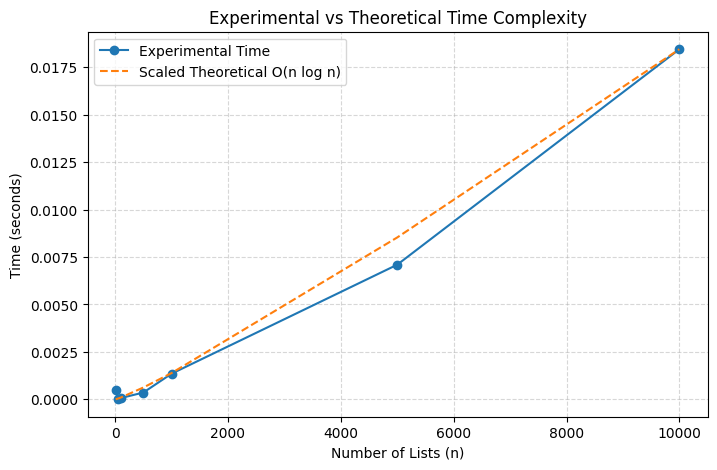

In [52]:
# Plotting Experimental vs Theoretical Time Complexity
plt.figure(figsize=(8,5))
plt.plot(df['n'], df['Experimental_Time'], 'o-', label='Experimental Time')
plt.plot(df['n'], df['Theoretical_Time']/max(df['Theoretical_Time'])*max(df['Experimental_Time']),    #theoretical value is scaled
         '--', label='Scaled Theoretical O(n log n)')
plt.xlabel('Number of Lists (n)')
plt.ylabel('Time (seconds)')
plt.title('Experimental vs Theoretical Time Complexity')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()